In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split        

In [3]:
dataset = pd.read_csv('kc_house_data.csv')

In [4]:
dataset.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
dataset.shape

(21613, 21)

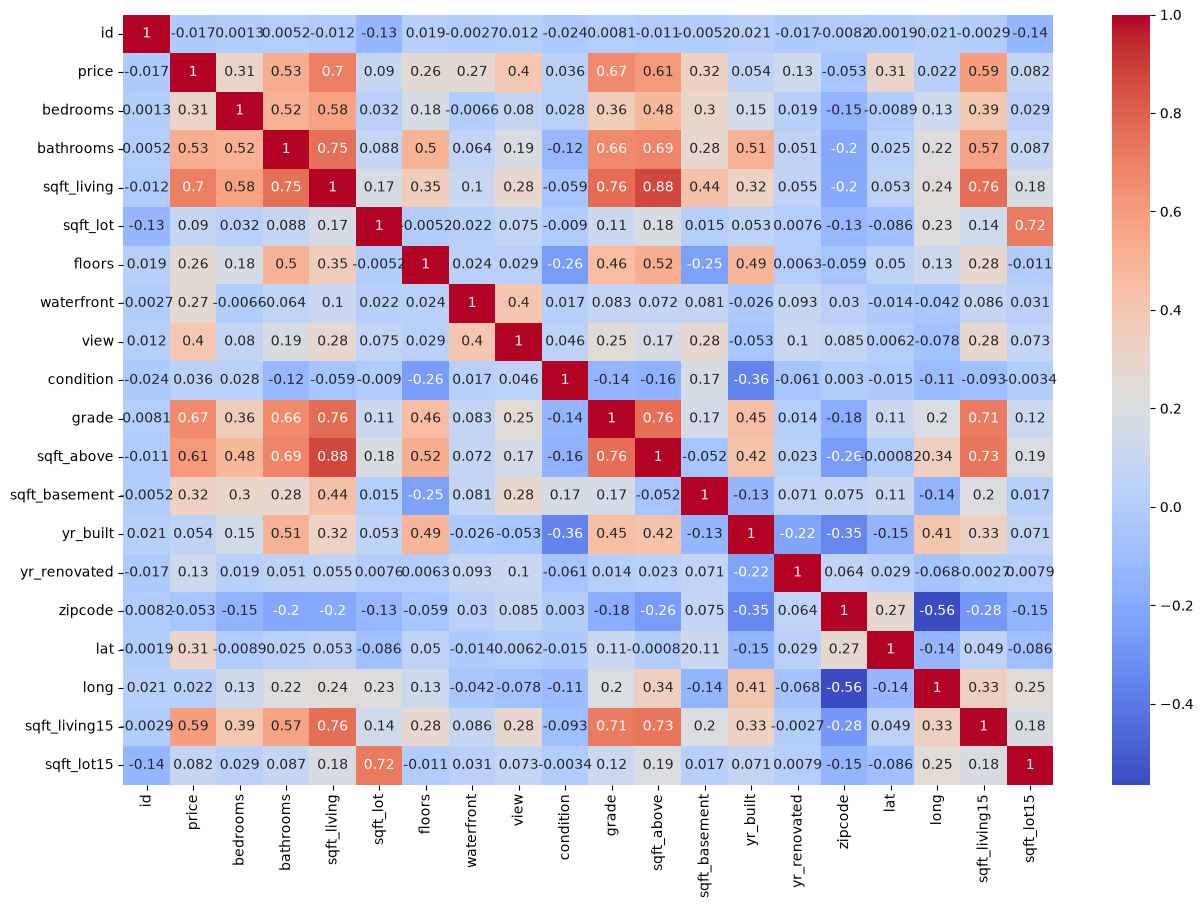

In [6]:
numeric_data = dataset.select_dtypes(include='number')

plt.figure(figsize=(15, 10))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [7]:
X = dataset.drop(columns=['price', 'date', 'id'])
y = dataset['price']

In [8]:
sc=StandardScaler()
sc.fit(X)
X_scaled = sc.transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)    

In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso 

In [11]:
from sklearn.metrics import mean_squared_error, r2_score    

In [12]:
import numpy as np

Linear Regression

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.score(X_test, y_test)*100


70.11904448878413

In [14]:
mean_squared_error(y_test, lr.predict(X_test))

45173046132.790146

In [15]:
mean_absolute_error = np.mean(np.abs(y_test - lr.predict(X_test))) 
mean_absolute_error 

np.float64(127493.34208656962)

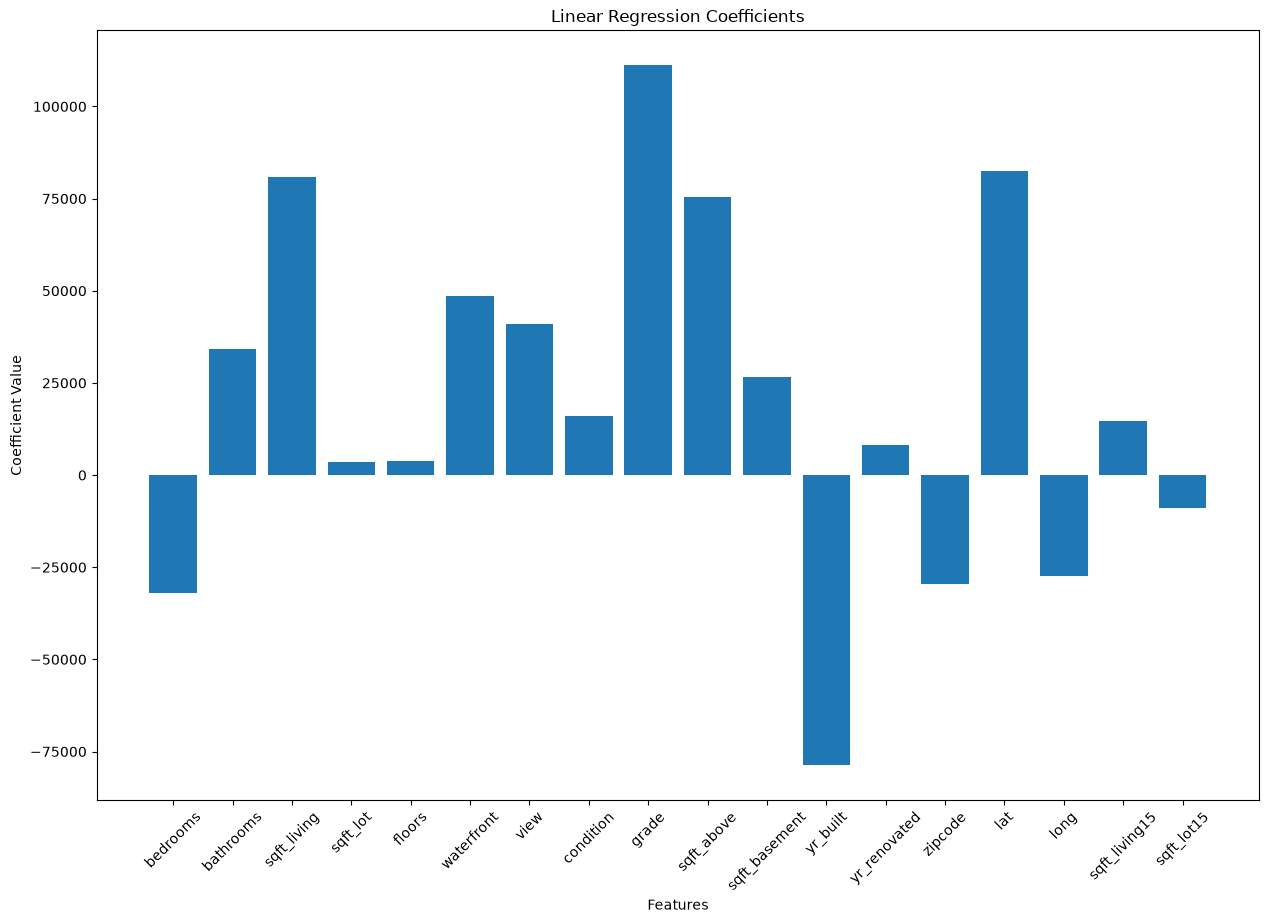

In [16]:
plt.figure(figsize=(15, 10))
plt.bar(X.columns, lr.coef_)    
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Linear Regression Coefficients')
plt.xticks(rotation=45)
plt.show()

In [17]:
lo = Lasso(alpha=0.1)
lo.fit(X_train, y_train)
lo.score(X_test, y_test)*100

c:\Users\dps23\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.006568e+13, tolerance: 2.259e+11
  model = cd_fast.enet_coordinate_descent(


70.11904184881843

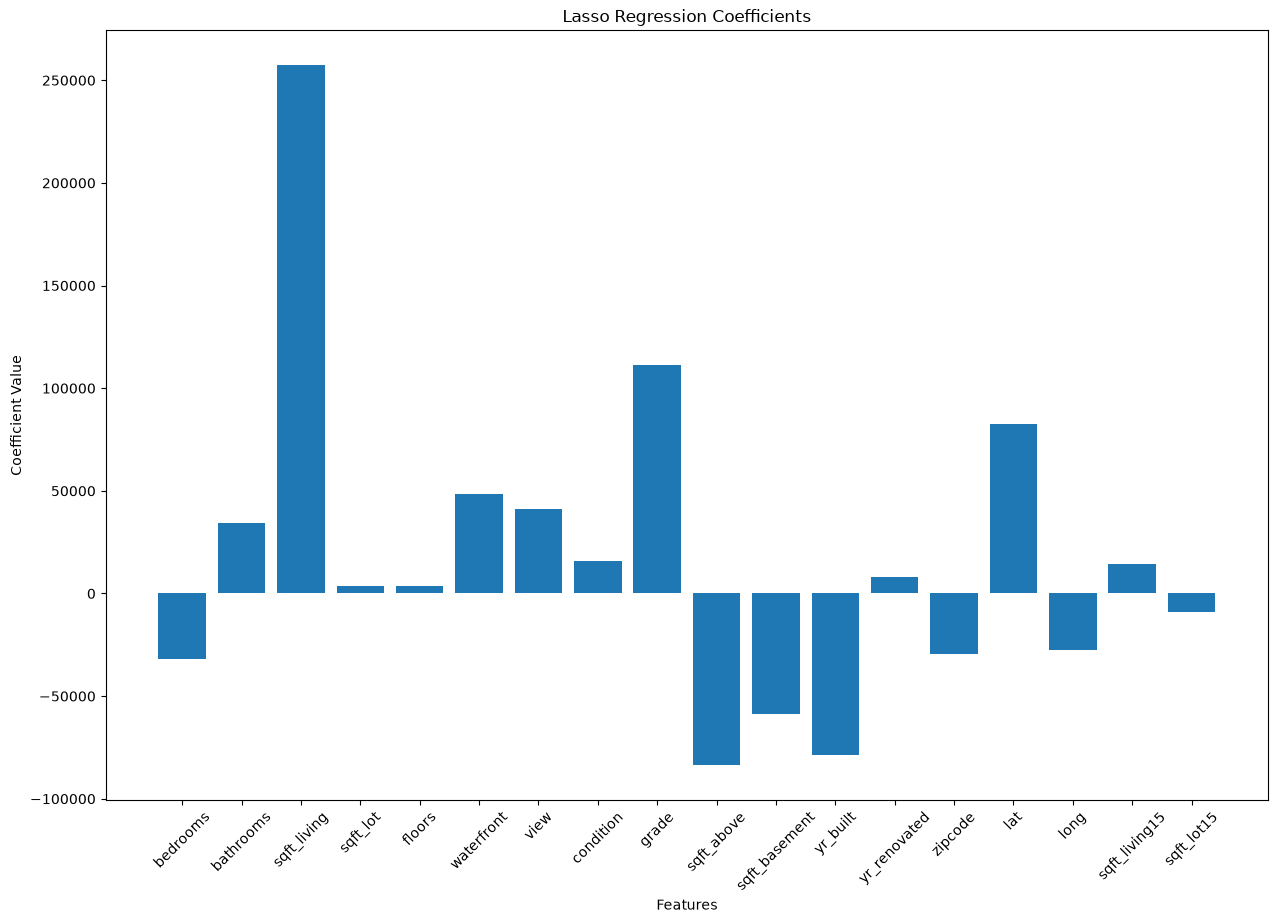

In [18]:
plt.figure(figsize=(15, 10))
plt.bar(X.columns, lo.coef_)
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression Coefficients')
plt.xticks(rotation=45)
plt.show()

In [19]:
ri = Ridge(alpha=0.1)
ri.fit(X_train, y_train)    
ri.score(X_test, y_test)*100

70.11902697686139

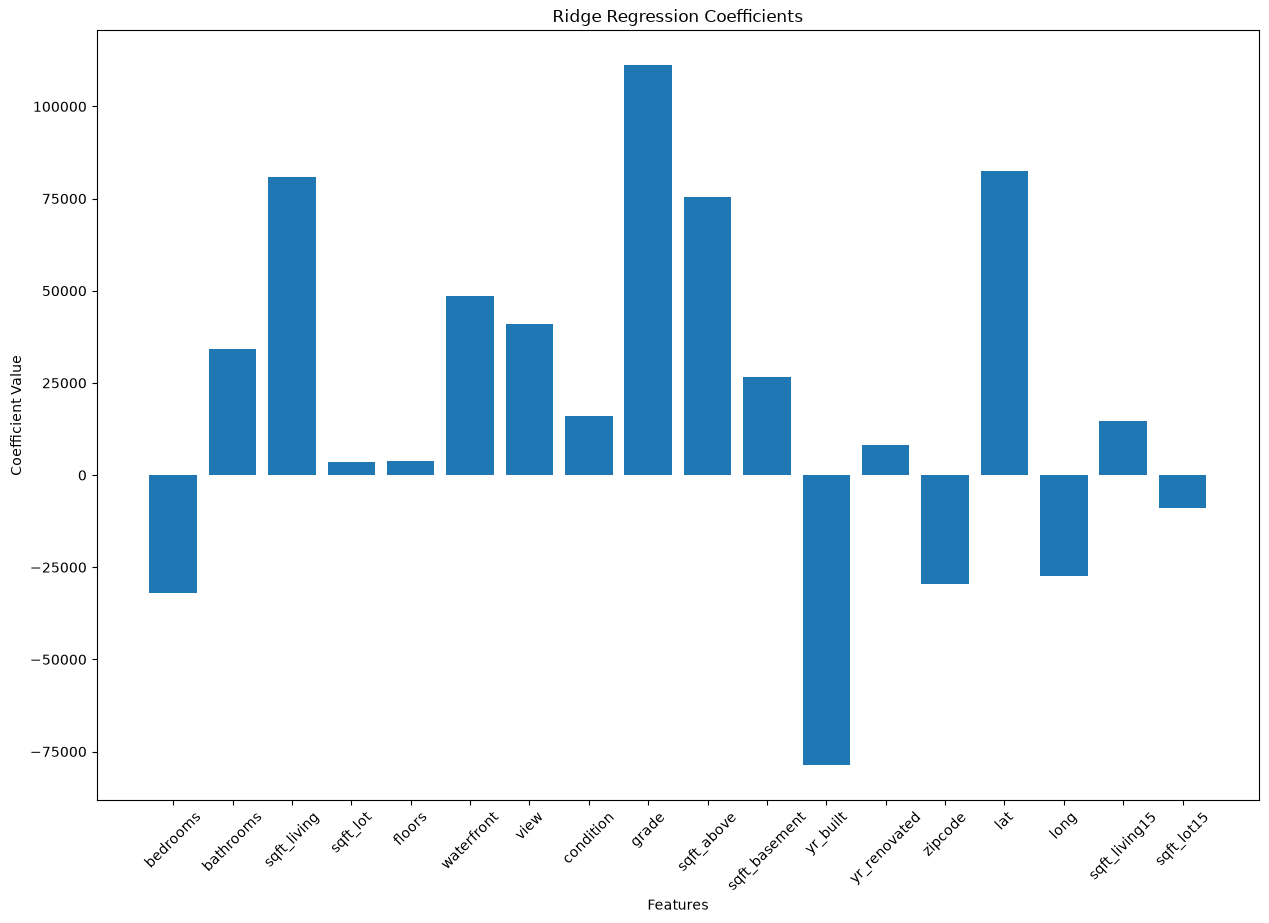

In [20]:

plt.figure(figsize=(15, 10))
plt.bar(X.columns, ri.coef_)    
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression Coefficients')
plt.xticks(rotation=45)
plt.show()


In [24]:
df=pd.DataFrame({
    "col_name": X.columns,
    "Linear_Regression": lr.coef_, "Lasso_Regression": lo.coef_, "Ridge_Regression": ri.coef_})
df

,col_name,Linear_Regression,Lasso_Regression,Ridge_Regression
0,bedrooms,-31933.323647,-31933.208463,-31932.652703
1,bathrooms,34321.164242,34320.500435,34320.970455
2,sqft_living,80795.073362,257280.342838,80794.579422
3,sqft_lot,3680.017707,3679.638809,3680.026990
4,floors,3781.524687,3781.504165,3781.712911
5,waterfront,48657.277095,48657.200998,48657.061689
6,view,41105.171777,41105.177536,41105.174896
7,condition,15960.216811,15960.102861,15960.389678
8,grade,111158.084778,111158.345153,111156.844659
9,sqft_above,75409.776432,-83713.407083,75409.214655
